In [ ]:



import os
from scipy.sparse import save_npz
import anndata as ad
import pandas as pd
import numpy as np
import scanpy as sc
from cellgrn.utils import construct_pseudo_bulk_pstime, compute_distance_matrix_all


[2025-11-18 19:31:20,077] INFO - sparsegrn._settings | Added StreamHandler with custom formatter to 'sparsegrn' logger.
/home/shaliu_fu/miniconda3/envs/sparsegrn/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
[2025-11-18 19:31:59,282] INFO - scMVP._settings | Added StreamHandler with custom formatter to 'scMVP' logger.


In [3]:
os.system(f"mkdir -p /home/shaliu_fu/multireg/multigrn/input_data/all_gene/10X_PBMC/")

input_rna = ad.read_h5ad(f"/home/shaliu_fu/multireg/benchmark/bench_dataset/10X_PBMC/PBMC-multiome-raw-RNA-counts.h5ad")
input_atac = ad.read_h5ad(f"/home/shaliu_fu/multireg/benchmark/bench_dataset/10X_PBMC/PBMC-multiome-raw-ATAC-peaks.h5ad")
input_meta = pd.read_csv(f"/home/shaliu_fu/multireg/benchmark/bench_dataset/10X_PBMC/metadata.csv",header=0)
input_meta.index = input_meta['barcode']
# scmvp_data = LoadH5ad(rna_ann=input_rna,atac_ann=input_atac,cell_meta=input_meta,cell_type_column_names='cell_type')
# out_umap = calc_umap_scmvp(scmvp_data)
# out_umap.to_csv(f"/home/shaliu_fu/multireg/benchmark/bench_dataset/scalability/{ncell}/umap.csv",index=True,header=True)
out_umap = pd.read_csv("/home/shaliu_fu/multireg/multigrn/input_data/top_gene/10X_PBMC/pbmc_umap.csv",header=0,index_col=0)
cell_latent =pd.read_csv("/home/shaliu_fu/multireg/multigrn/input_data/bench_dataset/10X_PBMC/cell_latent.csv",header=0)
#
# deg = pd.read_csv(f"/home/shaliu_fu/multireg/benchmark/bench_dataset/scalability/{ncell}/hvg.csv",header=None).iloc[:,0].values
# input_peak = pd.read_csv(f'/home/shaliu_fu/multireg/multigrn/input_data/top_gene/scalability/{ncell}/input_peak.txt',header=None).iloc[:,0].values


In [ ]:
adata = input_rna.copy()
adata.obs = input_meta
sc.pp.normalize_total(adata, target_sum=1e4)  
sc.pp.log1p(adata)  
sc.pp.highly_variable_genes(adata, n_top_genes=3000)  
adata = adata[:, adata.var["highly_variable"]] 
sc.pp.scale(adata) 
sc.pp.pca(adata, n_comps=50)  

sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30) 

sc.tl.leiden(adata, resolution=0.6)  

sc.tl.umap(adata)

sc.tl.paga(adata, groups='leiden')  
adata.uns['iroot'] = np.flatnonzero(adata.obs['leiden'] == '0')[0]

sc.tl.dpt(adata)  
sc.tl.umap(adata)  


/home/shaliu_fu/miniconda3/envs/sparsegrn/lib/python3.12/site-packages/scanpy/preprocessing/_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


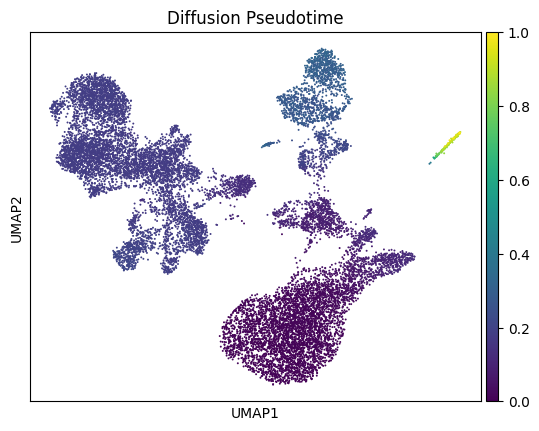

In [42]:
sc.pl.umap(adata, color=['dpt_pseudotime'], cmap='viridis', title="Diffusion Pseudotime")


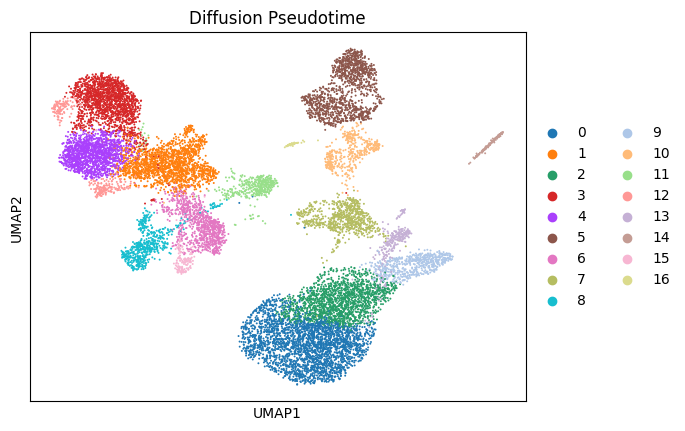

In [23]:
sc.pl.umap(adata, color=['leiden'], cmap='viridis', title="Diffusion Pseudotime")


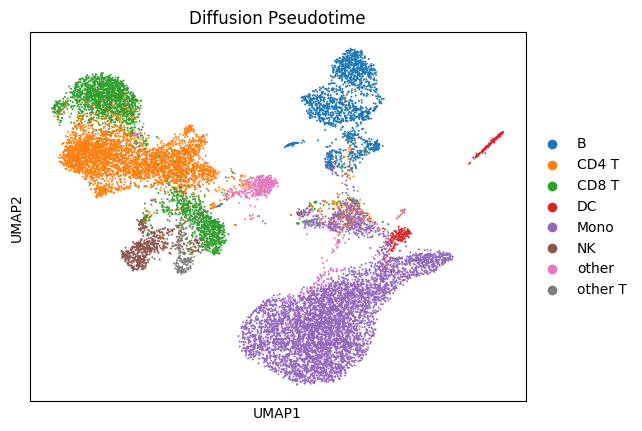

In [25]:
sc.pl.umap(adata, color=['annotated_labels'], cmap='viridis', title="Diffusion Pseudotime")


In [30]:
# pstime单独输出。
out_meta = adata.obs 


In [32]:
out_meta.to_csv("/home/shaliu_fu/multireg/multigrn/input_data/bench_dataset/10X_PBMC/metadata_pstime.csv",index=None, header=True)

In [39]:
df = pd.DataFrame(adata.obsm['X_pca'])
df.index = adata.obs.index.values
df.to_csv("/home/shaliu_fu/multireg/multigrn/input_data/bench_dataset/10X_PBMC/cell_latent.csv",index=None, header=True)

In [5]:
input_gene = [i.rstrip() for i in open('/home/shaliu_fu/multireg/multigrn/input_data/all_gene/10X_PBMC/input_gene.txt')]
input_peak = [i.rstrip() for i in open('/home/shaliu_fu/multireg/multigrn/input_data/all_gene/10X_PBMC/input_peak.txt')]

all_TF = [i.rstrip() for i in open("/home/shaliu_fu/multireg/multigrn/db/all_hg_TF.txt")]
input_tf = pd.DataFrame(list(set(all_TF) & set(input_gene)))

out_meta = pd.read_csv("/home/shaliu_fu/multireg/multigrn/input_data/bench_dataset/10X_PBMC/metadata_pstime.csv",header=0)
out_meta.index = out_meta['barcode']

In [18]:
cell_latent.index = out_umap.index.values
joint_latent = pd.concat([cell_latent,out_umap],axis=1)

In [19]:
joint_latent.shape

(15021, 52)

In [29]:
pseduo_bulk_latent.iloc[:,:50].to_csv("/home/shaliu_fu/multireg/multigrn/input_data/all_gene/10X_PBMC/ps_latent.csv",header=True,index=True)# 前50列是latent，后2列是umap.
pseduo_bulk_latent.iloc[:,50:].to_csv("/home/shaliu_fu/multireg/multigrn/input_data/all_gene/10X_PBMC/ps_umap.csv",header=True,index=True)#

In [ ]:
pseudo_bulk_rna, pseudo_bulk_atac, pseudo_bulk_meta  =  \
                                    construct_pseudo_bulk_pstime(rna_input,
                                    atac_input,
                                    out_meta['dpt_pseudotime'], out_meta['annotated_labels'], n_cell=5)


pseudo_bulk_rna=pseudo_bulk_rna.apply(lambda x: x / x.sum() * 1000, axis=1)
pseudo_bulk_atac=pseudo_bulk_atac.apply(lambda x: x / x.sum() * 1000, axis=1)

pseudo_bulk_tf = pseudo_bulk_rna.loc[:,list(input_tf[0])]
np.savez_compressed(f'/home/shaliu_fu/multireg/multigrn/input_data/all_gene/10X_PBMC/pseudo_data_pstime.npz', 
                rna=pseudo_bulk_rna, 
                atac=pseudo_bulk_atac,
                tf=pseudo_bulk_tf,
                meta=pseudo_bulk_meta)         

In [15]:
gene_peak_dist, promoter_mat, gene_name_out, peak_name_out = \
                                         compute_distance_matrix_all(gene_bed_file="/home/shaliu_fu/multireg/multigrn/db/hg38_prom_normal.bed",
                                         peak_bed_file=f"/home/shaliu_fu/multireg/multigrn/input_data/top_gene/10X_PBMC/pbmc_peak.bed",
                                         gene_names=input_rna.var.index.values)

Processing chromosome: chr1
Processing chromosome: chr10
Processing chromosome: chr11
Processing chromosome: chr12
Processing chromosome: chr13
Processing chromosome: chr14
Processing chromosome: chr15
Processing chromosome: chr16
Processing chromosome: chr17
Processing chromosome: chr18
Processing chromosome: chr19
Processing chromosome: chr2
Processing chromosome: chr20
Processing chromosome: chr21
Processing chromosome: chr22
Processing chromosome: chr3
Processing chromosome: chr4
Processing chromosome: chr5
Processing chromosome: chr6
Processing chromosome: chr7
Processing chromosome: chr8
Processing chromosome: chr9
Processing chromosome: chrM
Processing chromosome: chrX
Processing chromosome: chrY


In [16]:
save_npz(f'/home/shaliu_fu/multireg/multigrn/input_data/all_gene/10X_PBMC/gene_peak_dist_all.npz', gene_peak_dist)
gene_name_out.to_csv(f'/home/shaliu_fu/multireg/multigrn/input_data/all_gene/10X_PBMC/input_gene.txt',header=None,index=None)
peak_name_out.to_csv(f'/home/shaliu_fu/multireg/multigrn/input_data/all_gene/10X_PBMC/input_peak.txt',header=None,index=None)
save_npz(f'/home/shaliu_fu/multireg/multigrn/input_data/all_gene/10X_PBMC/all_prom_mat.npz',promoter_mat)

all_TF = [i.rstrip() for i in open("/home/shaliu_fu/multireg/multigrn/db/all_hg_TF.txt")]
input_tf = pd.DataFrame(list(set(all_TF) & set(gene_name_out)))

input_tf.to_csv(f'/home/shaliu_fu/multireg/multigrn/input_data/all_gene/10X_PBMC/input_tf.txt',header=None,index=None)


In [ ]:
# import scanpy as sc
# ps_data = np.load('/home/shaliu_fu/multireg/multigrn/input_data/all_gene/10X_PBMC/pseudo_data.npz', allow_pickle=True)
# new_meta = np.load('/home/shaliu_fu/multireg/multigrn/input_data/top_gene/10X_PBMC/pseudo_data_pstime.npz', allow_pickle=True)['meta']

In [ ]:
# data_dict = {key: ps_data[key] for key in ps_data.files}

# # 修改meta变量
# data_dict['meta'] = new_meta

# np.savez_compressed(
#     '/home/shaliu_fu/multireg/multigrn/input_data/all_gene/10X_PBMC/pseudo_data_pstime.npz',
#     **data_dict  # 解包字典，保存所有变量
# )